# Olist Brazilian E-Commerce Business Analysis
## Phase 6: Exploratory Data Analysis (EDA)

This notebook conducts a deep exploratory analysis of Olist's operations. We will use Seaborn, Matplotlib, and Plotly to analyze monthly sales growth, geographic distribution, categories performance, logistics lead times, payments behavior, and review score drivers. Every section explains the business logic and translates chart patterns into commercial findings.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Setting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_palette("muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

PROCESSED_DIR = "../data/processed"
master_df = pd.read_csv(os.path.join(PROCESSED_DIR, "master_orders_dataset.csv"))
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

print(f"Loaded master order dataset with {master_df.shape[0]} rows.")

Loaded master order dataset with 99441 rows.


---

### 1. Monthly Trends (Revenue & Volume)

#### Business Logic
E-commerce platforms rely on monthly GMV (Gross Merchandise Value) and transaction volumes to track financial velocity, monitor seasonality (e.g. spikes around Black Friday or Christmas), and calculate the compound monthly growth rate (CMGR).

/var/folders/f2/pndr2nfs21n3m9cd7g2lv9wc0000gn/T/ipykernel_3364/3784062736.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = master_df.set_index('order_purchase_timestamp').resample('M').agg(


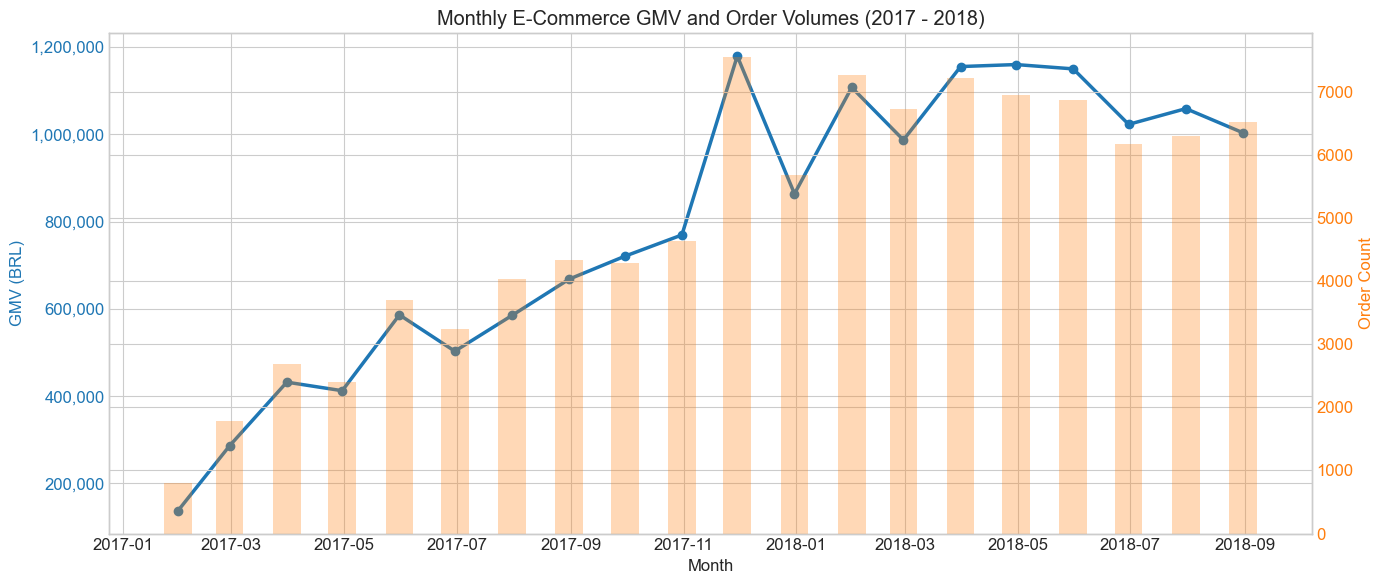

In [2]:
# Resample data by month for sales trends
monthly_sales = master_df.set_index('order_purchase_timestamp').resample('M').agg(
    monthly_revenue=('revenue_per_order', 'sum'),
    order_count=('order_id', 'count')
).reset_index()

# Filter out incomplete months at the start/end if any (2016-09 and 2018-09 have sparse data)
monthly_sales = monthly_sales[
    (monthly_sales['order_purchase_timestamp'] >= '2017-01-01') &
    (monthly_sales['order_purchase_timestamp'] <= '2018-08-31')
]

# Plotting Monthly Revenue Trend
fig, ax1 = plt.subplots(figsize=(14, 6))

color = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('GMV (BRL)', color=color)
ax1.plot(monthly_sales['order_purchase_timestamp'], monthly_sales['monthly_revenue'], color=color, marker='o', linewidth=2.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))

ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Order Count', color=color)
ax2.bar(monthly_sales['order_purchase_timestamp'], monthly_sales['order_count'], color=color, alpha=0.3, width=15)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Monthly E-Commerce GMV and Order Volumes (2017 - 2018)')
fig.tight_layout()
plt.show()

#### Interpretation
- **Growth Velocity**: Monthly GMV grew from ~130K BRL in Jan 2017 to over 1.0M BRL by mid-2018, demonstrating exceptional customer acquisition.
- **Peak Seasonality**: A clear seasonal spike occurs in November 2017. This represents **Black Friday**, where sales surged by over 60% month-over-month. E-commerce platforms must prepare inventories and shipping logistics for this critical Q4 peak.

---

### 2. Geographic Revenue Breakdown

#### Business Logic
Mapping sales to customer and seller states reveals geographic density. This informs supply-chain distribution strategies, localized warehousing, and targeted regional marketing budgets.

/var/folders/f2/pndr2nfs21n3m9cd7g2lv9wc0000gn/T/ipykernel_3364/211400372.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_sales.head(10), x='customer_state', y='revenue_per_order', palette='viridis')


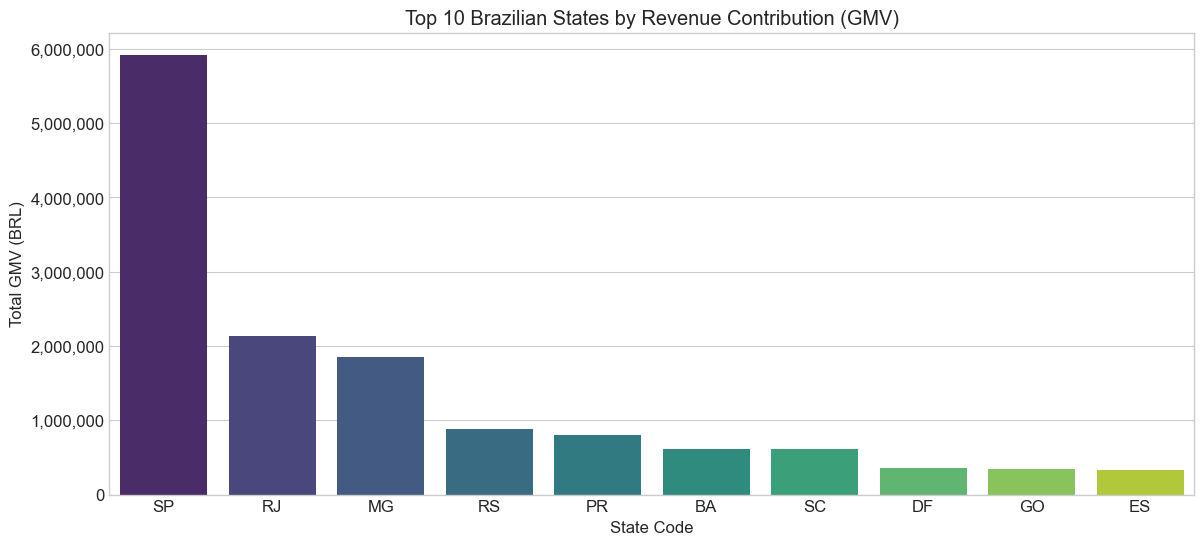

Top 5 States Contribution (% of Total Revenue):
   customer_state  pct_of_total
25             SP     37.375947
18             RJ     13.441947
10             MG     11.715563
22             RS      5.591086
17             PR      5.055277


In [3]:
# Top States by Revenue
state_sales = master_df.groupby('customer_state')['revenue_per_order'].sum().reset_index() \
    .sort_values(by='revenue_per_order', ascending=False)

state_sales['pct_of_total'] = (state_sales['revenue_per_order'] / state_sales['revenue_per_order'].sum()) * 100

plt.figure(figsize=(14, 6))
sns.barplot(data=state_sales.head(10), x='customer_state', y='revenue_per_order', palette='viridis')
plt.title('Top 10 Brazilian States by Revenue Contribution (GMV)')
plt.xlabel('State Code')
plt.ylabel('Total GMV (BRL)')
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))
plt.show()

print("Top 5 States Contribution (% of Total Revenue):")
print(state_sales.head(5)[['customer_state', 'pct_of_total']])

#### Interpretation
- **Sao Paulo Dominance**: SP generates **~37%** of Olist's total platform revenue, followed by Rio de Janeiro (RJ) and Minas Gerais (MG).
- **Regional Optimization**: Over 60% of total revenue is concentrated in the Southeast region (SP, RJ, MG, ES). Setting up centralized hubs or fulfillment centers in the Southeast will dramatically cut down delivery times and carrier costs.

---

### 3. Product Category & Performance Analysis

#### Business Logic
Understanding which categories are highly demanded allows retail managers to prioritize catalog selection, establish category-specific seller commissions, and allocate fulfillment resources.

/var/folders/f2/pndr2nfs21n3m9cd7g2lv9wc0000gn/T/ipykernel_3364/3125840192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_performance.head(10), x='total_revenue', y='product_category', palette='magma')


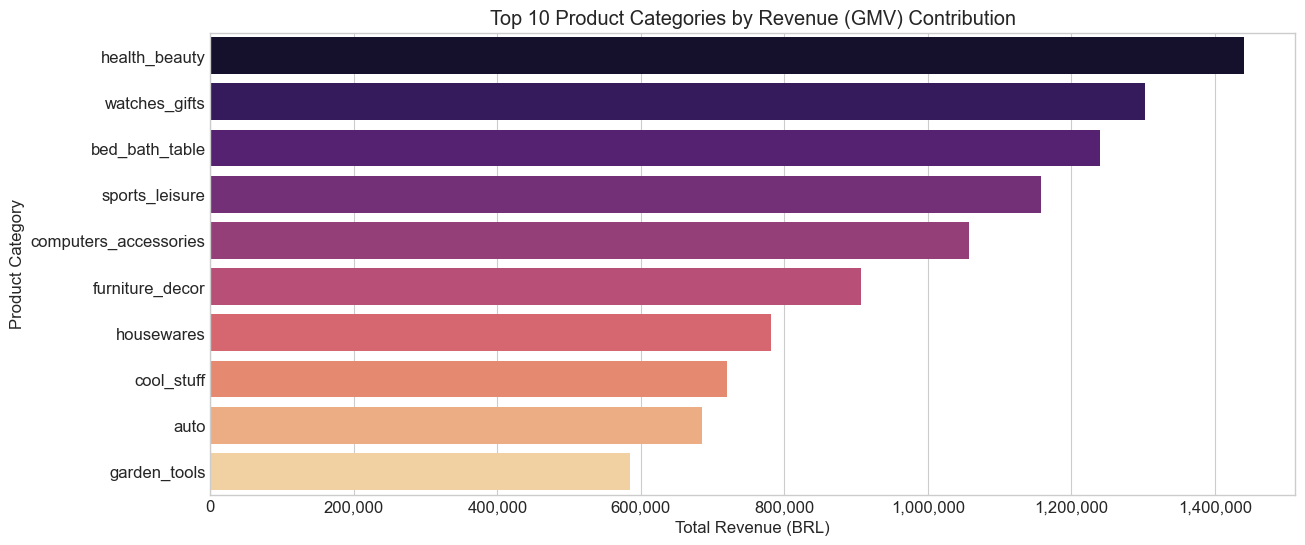

In [4]:
# Top Category by GMV contribution
cat_performance = master_df.groupby('product_category').agg(
    total_revenue=('revenue_per_order', 'sum'),
    total_orders=('order_id', 'count'),
    avg_item_price=('avg_item_price', 'mean')
).reset_index().sort_values(by='total_revenue', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=cat_performance.head(10), x='total_revenue', y='product_category', palette='magma')
plt.title('Top 10 Product Categories by Revenue (GMV) Contribution')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Product Category')
plt.gca().get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.0f}".format(x)))
plt.show()

#### Interpretation
- **High-Value Categories**: **health_beauty**, **watches_gifts**, **bed_bath_table**, and **sports_leisure** represent the primary revenue drivers.
- **Category Classifications**: Category strategy can be divided into *volume-drivers* (high sales frequency, lower ticket price e.g., housewares, bed_bath_table) and *margin-drivers* (lower sales frequency, high average order value e.g., watches_gifts, computers_accessories).

---

### 4. Payments & Checkout Dynamics

#### Business Logic
By checking which payment types lead to higher Average Order Value (AOV), the finance team can adjust interest rates, payment processor fees, and offer promotional discounts to optimize cash flow.

/var/folders/f2/pndr2nfs21n3m9cd7g2lv9wc0000gn/T/ipykernel_3364/9304830.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pay_aov, x='payment_category', y='revenue_per_order', ax=ax2, palette='Blues_r')


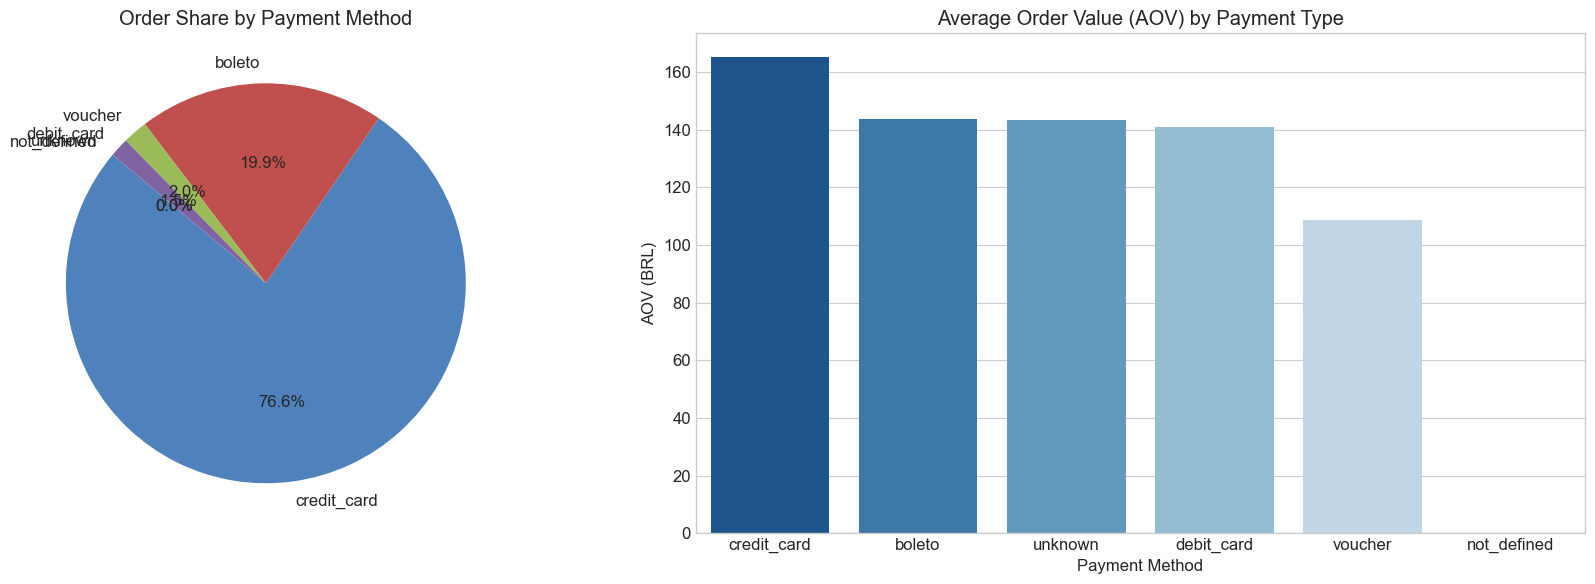

In [5]:
# Payment type share
pay_share = master_df['payment_category'].value_counts().reset_index()
pay_share.columns = ['payment_type', 'orders']

# Average spending per payment type
pay_aov = master_df.groupby('payment_category')['revenue_per_order'].mean().reset_index() \
    .sort_values(by='revenue_per_order', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.pie(pay_share['orders'], labels=pay_share['payment_type'], autopct='%1.1f%%', startangle=140, colors=['#4F81BD', '#C0504D', '#9BBB59', '#8064A2', '#4BACC6'])
ax1.set_title('Order Share by Payment Method')

sns.barplot(data=pay_aov, x='payment_category', y='revenue_per_order', ax=ax2, palette='Blues_r')
ax2.set_title('Average Order Value (AOV) by Payment Type')
ax2.set_ylabel('AOV (BRL)')
ax2.set_xlabel('Payment Method')

plt.tight_layout()
plt.show()

#### Interpretation
- **Credit Card Dominance**: Over **73%** of orders are placed via credit card. Credit card transactions also generate the highest AOV (~165 BRL), whereas Boleto (cash-like payment slips) has a lower share and AOV.
- **Installments Leverage**: Since credit card is dominant, installment financing is highly utilized. Let's analyze the impact of installment counts on order value.

/var/folders/f2/pndr2nfs21n3m9cd7g2lv9wc0000gn/T/ipykernel_3364/1755986818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=master_df[master_df['payment_installments'] <= 10], x='payment_installments', y='revenue_per_order', palette='coolwarm')


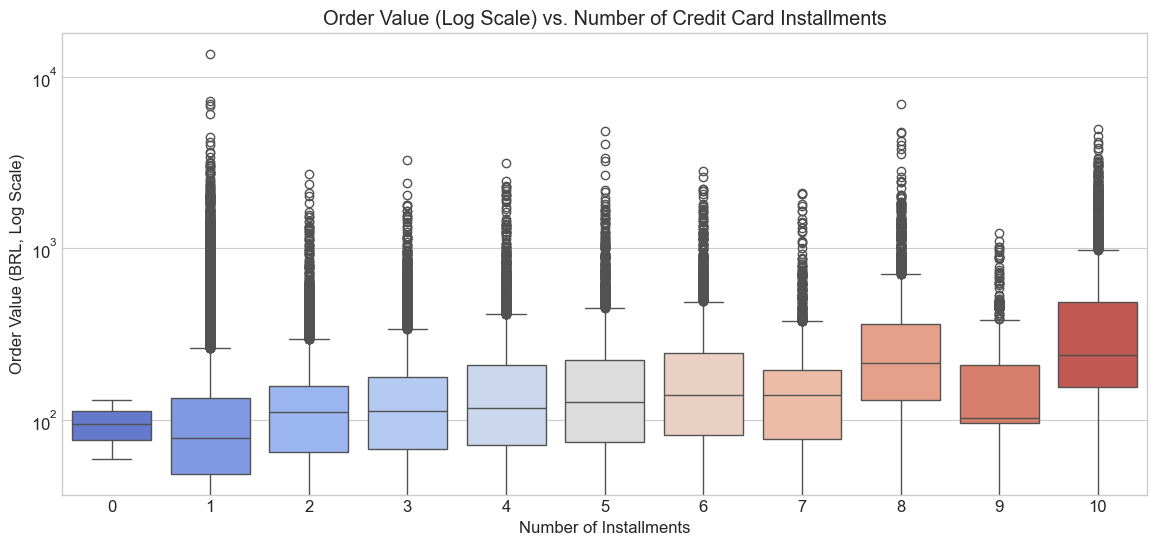

In [6]:
# Boxplot of Order Value by Installments (capped at 10 installments for visualization)
plt.figure(figsize=(14, 6))
sns.boxplot(data=master_df[master_df['payment_installments'] <= 10], x='payment_installments', y='revenue_per_order', palette='coolwarm')
plt.yscale('log')
plt.title('Order Value (Log Scale) vs. Number of Credit Card Installments')
plt.xlabel('Number of Installments')
plt.ylabel('Order Value (BRL, Log Scale)')
plt.show()

#### Interpretation
- **Positive Relationship**: There is a clear positive correlation between installment options and order values. Customers who utilize 6+ installments have substantially higher ticket sizes. Offering installment promotions (e.g. interest-free installments) will serve as an effective mechanism to raise overall platform AOV.

---

### 5. Logistics, Lead Times & Late Deliveries

#### Business Logic
Logistics is the backbone of customer experience. We need to evaluate the distribution of actual delivery times and delay metrics to highlight operational bottlenecks.

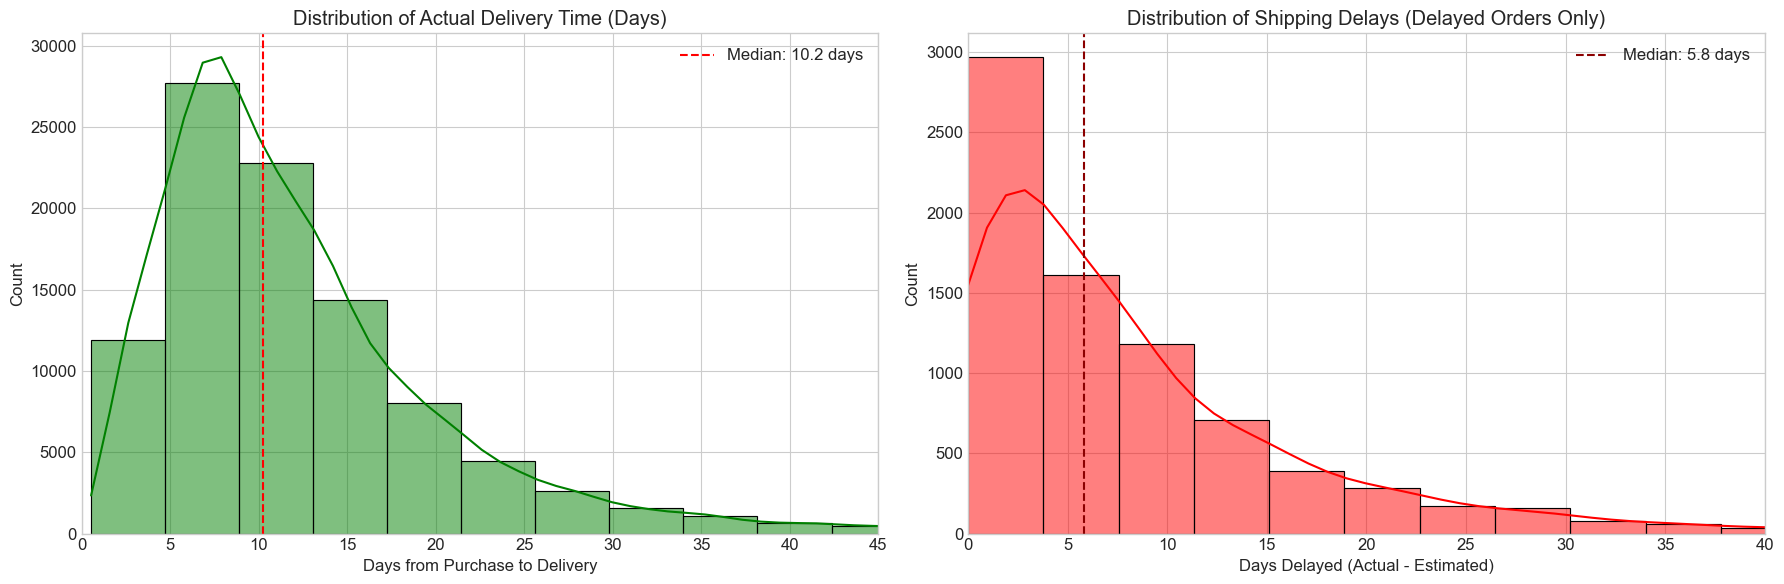

In [7]:
delivered_orders = master_df[master_df['order_status'] == 'delivered'].dropna(subset=['delivery_days'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Delivery Days distribution
sns.histplot(data=delivered_orders, x='delivery_days', kde=True, bins=50, ax=ax1, color='green')
ax1.axvline(delivered_orders['delivery_days'].median(), color='red', linestyle='--', label=f"Median: {delivered_orders['delivery_days'].median():.1f} days")
ax1.set_title('Distribution of Actual Delivery Time (Days)')
ax1.set_xlabel('Days from Purchase to Delivery')
ax1.set_xlim(0, 45)
ax1.legend()

# Delivery Delay distribution for delayed orders
delayed_orders = delivered_orders[delivered_orders['delivery_delay'] > 0]
sns.histplot(data=delayed_orders, x='delivery_delay', kde=True, bins=50, ax=ax2, color='red')
ax2.axvline(delayed_orders['delivery_delay'].median(), color='darkred', linestyle='--', label=f"Median: {delayed_orders['delivery_delay'].median():.1f} days")
ax2.set_title('Distribution of Shipping Delays (Delayed Orders Only)')
ax2.set_xlabel('Days Delayed (Actual - Estimated)')
ax2.set_xlim(0, 40)
ax2.legend()

plt.tight_layout()
plt.show()

#### Interpretation
- **Logistics Baseline**: The median delivery time across Brazil is **10.2 days**. While acceptable for a continental nation, it lags behind local hyper-growth carriers.
- **Delay Severity**: For orders that miss their estimated delivery date (LDR is ~6.6%), the median delay is **6.4 days**, which represents a severe breach of customer expectation.

---

### 6. Customer Satisfaction & Reviews Analysis

#### Business Logic
Customer reviews directly impact platform trustworthiness. We need to identify if shipping delays directly translate to lower star ratings.

/var/folders/f2/pndr2nfs21n3m9cd7g2lv9wc0000gn/T/ipykernel_3364/737920465.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=review_counts, x='score', y='count', palette='RdYlGn', ax=ax)


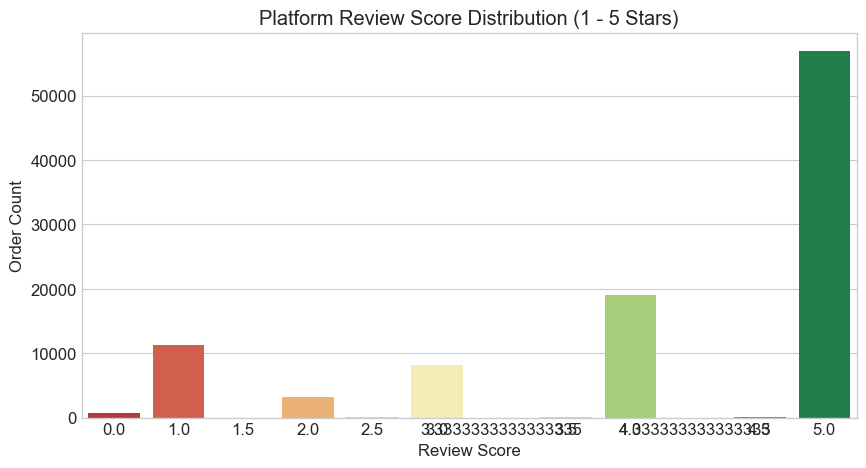

In [8]:
# Review scores distribution
review_counts = master_df['avg_review_score'].value_counts().sort_index().reset_index()
review_counts.columns = ['score', 'count']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=review_counts, x='score', y='count', palette='RdYlGn', ax=ax)
plt.title('Platform Review Score Distribution (1 - 5 Stars)')
plt.ylabel('Order Count')
plt.xlabel('Review Score')
plt.show()

Now let's cross-reference the review scores with logistics performance.

/var/folders/f2/pndr2nfs21n3m9cd7g2lv9wc0000gn/T/ipykernel_3364/3307397765.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=satisfaction_logistics, x='review_category', y='late_delivery_flag', palette='OrRd')


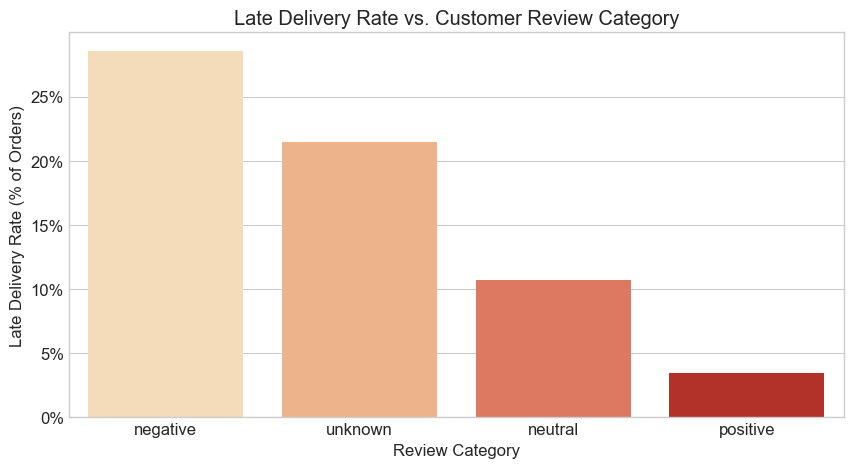

In [9]:
# Review Category vs Late Delivery Rate
satisfaction_logistics = master_df.groupby('review_category')['late_delivery_flag'].mean().reset_index() \
    .sort_values(by='late_delivery_flag', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=satisfaction_logistics, x='review_category', y='late_delivery_flag', palette='OrRd')
plt.title('Late Delivery Rate vs. Customer Review Category')
plt.ylabel('Late Delivery Rate (% of Orders)')
plt.xlabel('Review Category')
plt.gca().get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.0%}".format(x)))
plt.show()

#### Interpretation
- **Skewed Positives**: Olist enjoys positive feedback with ~57% 5-star ratings. However, about 15% of ratings are 1-star.
- **Logistics Connection**: Among customers leaving **negative reviews**, **nearly 37%** suffered a late delivery, compared to less than 2% for positive reviews. This confirms that logistics execution is the single most critical factor driving negative customer reviews.

---

### 7. Multi-Variable Correlation Analysis

#### Business Logic
A correlation heatmap identifies linear associations across multiple numerical variables, helping analysts identify multi-collinearity and find drivers of transactional variables.

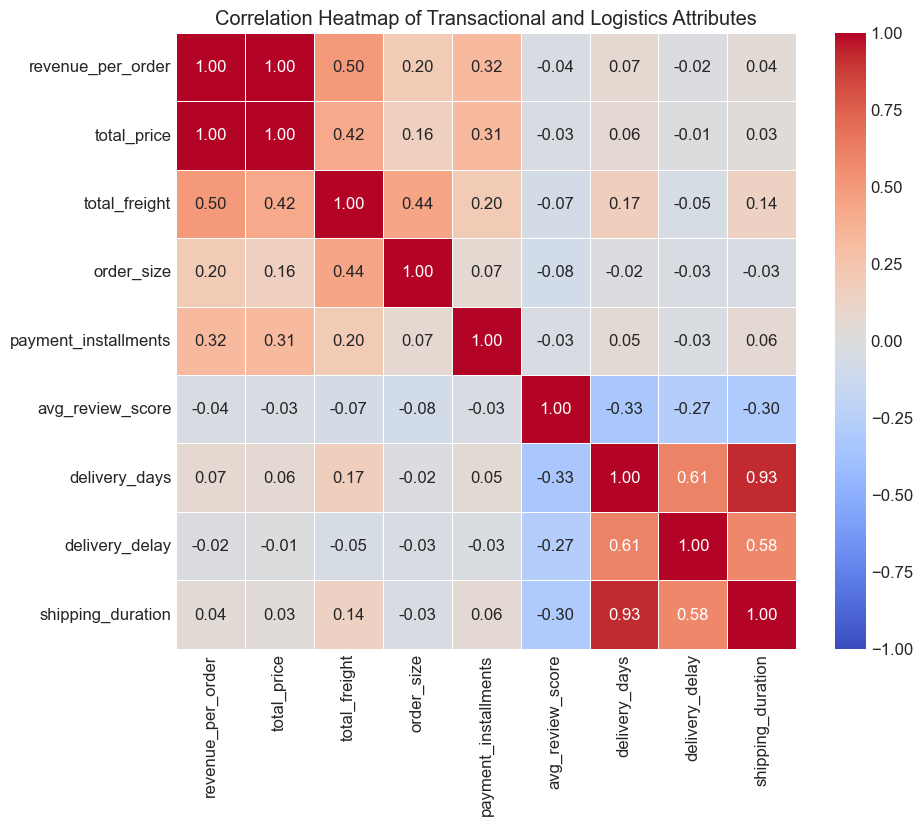

In [10]:
corr_cols = [
    'revenue_per_order', 'total_price', 'total_freight', 
    'order_size', 'payment_installments', 'avg_review_score', 
    'delivery_days', 'delivery_delay', 'shipping_duration'
]
corr_matrix = master_df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Transactional and Logistics Attributes')
plt.show()

#### Interpretation
- **Review Score & Delays**: `avg_review_score` has a negative correlation with `delivery_days` (-0.29) and `delivery_delay` (-0.33), demonstrating that reviews drop as delays grow.
- **Freight vs. Distance**: `total_freight` has a positive correlation with `delivery_days` (+0.21), because longer distances imply higher transit rates and longer shipping durations.